# **Modelagem de Imagens Médicas com Grafos de Adjacência de Regiões (RAG)**

### **Configurações**

In [2]:
import os
import glob
import matplotlib.pyplot as plt
import nibabel as nib
import networkx as nx
import os
from pathlib import Path
import nibabel as nib
import numpy as np
import pandas as pd

from skimage.segmentation import slic, mark_boundaries
from skimage.measure import regionprops

### **Construção do Grafo de Adjacência de Regiões (RAG)**

O grafo é construído a partir dos superpixels, onde cada região representa um nó e as adjacências espaciais definem as arestas.

In [3]:
def construir_rag(segmentos):

    G = nx.Graph()

    labels = np.unique(segmentos)

    for label in labels:
        G.add_node(int(label))

    linhas, colunas = segmentos.shape

    for i in range(linhas - 1):
        for j in range(colunas - 1):

            atual = segmentos[i, j]

            direita = segmentos[i, j + 1]
            baixo = segmentos[i + 1, j]

            if atual != direita:
                G.add_edge(int(atual), int(direita))

            if atual != baixo:
                G.add_edge(int(atual), int(baixo))

            # diagonais
            if i < linhas - 1 and j < colunas - 1:
                diag1 = segmentos[i + 1, j + 1]
                if atual != diag1:
                    G.add_edge(int(atual), int(diag1))

            if i < linhas - 1 and j > 0:
                diag2 = segmentos[i + 1, j - 1]
                if atual != diag2:
                    G.add_edge(int(atual), int(diag2))

    return G

In [4]:
def rotular_superpixels(props, mask_slice):
    labels = {}
    pos = {}

    for regiao in props:
        coords = regiao.coords
        valores = mask_slice[coords[:, 0], coords[:, 1]]

        tumor_ratio = np.mean(valores > 0)

        label = regiao.label
        labels[label] = "tumor" if tumor_ratio > 0.5 else "normal"

        y, x = regiao.centroid
        pos[label] = (x, y)

    return labels, pos

In [5]:
def calcular_metricas(G, labels_superpixel):

    grau_tumor = []
    grau_normal = []

    for node in G.nodes():
        grau = G.degree(node)

        if labels_superpixel[node] == "tumor":
            grau_tumor.append(grau)
        else:
            grau_normal.append(grau)

    return {
        "densidade": nx.density(G),
        "componentes": nx.number_connected_components(G),
        #"maior_comp": len(max(nx.connected_components(G), key=len)),
        "grau_tumor": np.mean(grau_tumor),
        "grau_normal": np.mean(grau_normal),
    }

### **Carregamento e Pré-processamento da Base BraTS 2020**

In [6]:
raiz = Path(r"DATASET")

pacientes = sorted(raiz.glob("BraTS20_*"))
pasta_paciente = pacientes[0]

flair_path = next(pasta_paciente.glob("*flair*"), None)
mask_path = next(pasta_paciente.glob("*seg*"), None)

if not flair_path or not mask_path:
    raise FileNotFoundError("Arquivos FLAIR ou SEG não foram encontrados na pasta do paciente.")

# PROCESSAMENTO DAS IMAGENS
# Processar imagem FLAIR Fatia 75
img = nib.load(str(flair_path)).get_fdata()
slice_img = np.rot90(img[:, :, 75])

# Normalização Min-Max
img_norm = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min() + 1e-8)

# Processar Mascara
mask = nib.load(str(mask_path)).get_fdata()
mask_slice = np.rot90(mask[:, :, 75])

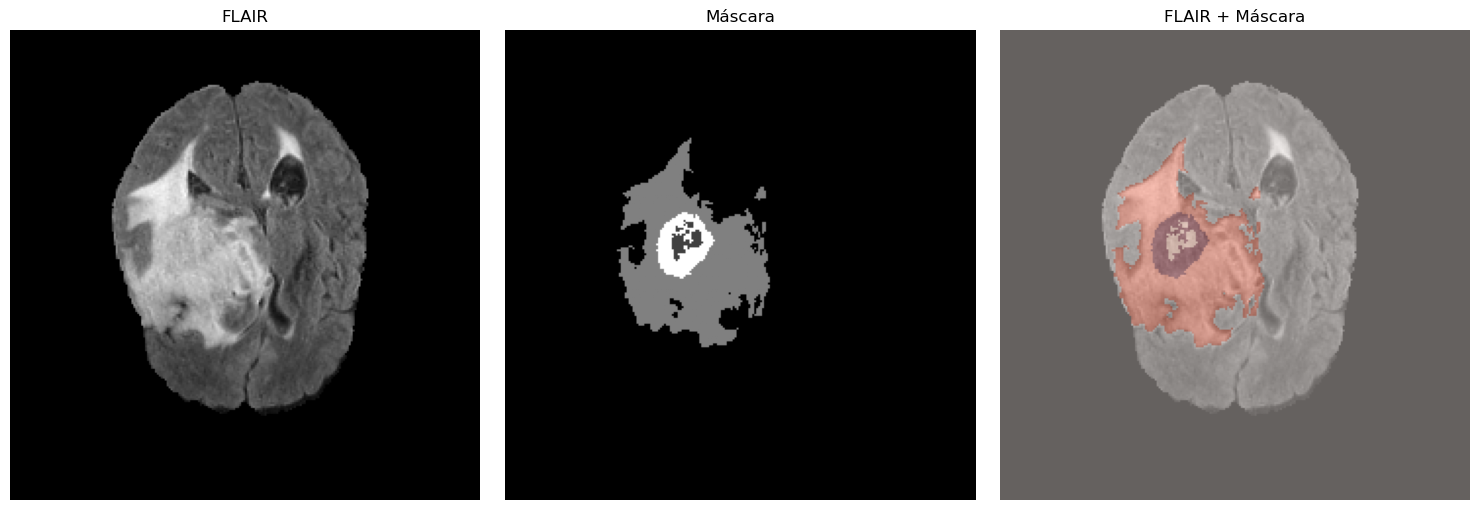

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(slice_img, cmap="gray")
axes[0].set_title("FLAIR")
axes[0].axis("off")

axes[1].imshow(mask_slice, cmap="gray")
axes[1].set_title("Máscara")
axes[1].axis("off")

axes[2].imshow(slice_img, cmap="gray")
axes[2].imshow(mask_slice, cmap="Reds", alpha=0.4)
axes[2].set_title("FLAIR + Máscara")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### **Experimento: Variação do número de superpixels**

Executando Experimento - n_segments = 200
Nós: 176
Arestas: 506
Densidade: 0.0329
Componentes: 1


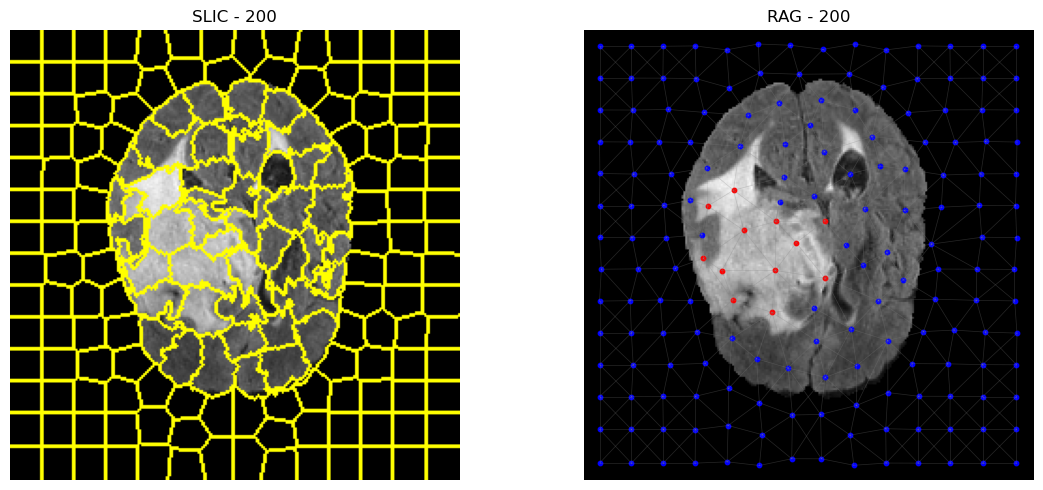

Executando Experimento - n_segments = 400
Nós: 372
Arestas: 1198
Densidade: 0.0174
Componentes: 1


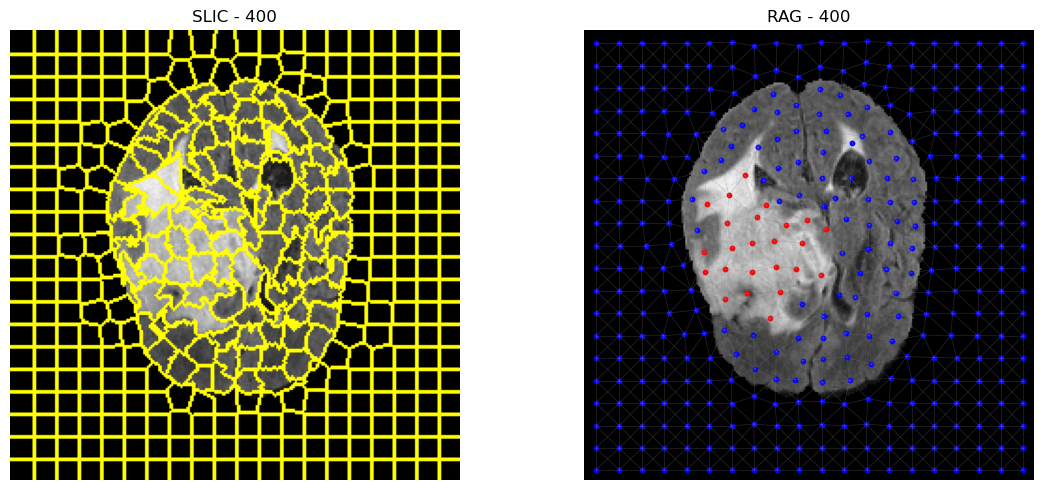

Executando Experimento - n_segments = 600
Nós: 546
Arestas: 1818
Densidade: 0.0122
Componentes: 1


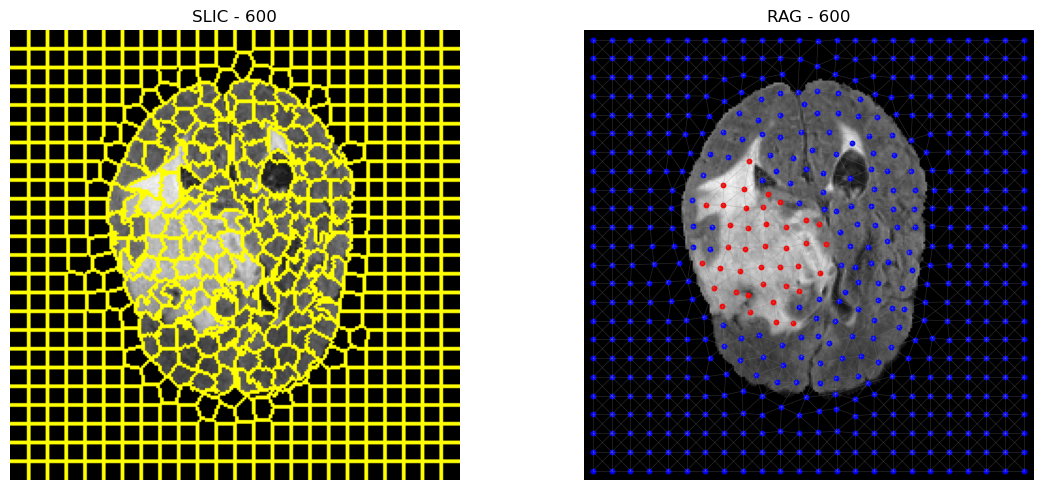

Executando Experimento - n_segments = 800
Nós: 854
Arestas: 2928
Densidade: 0.0080
Componentes: 1


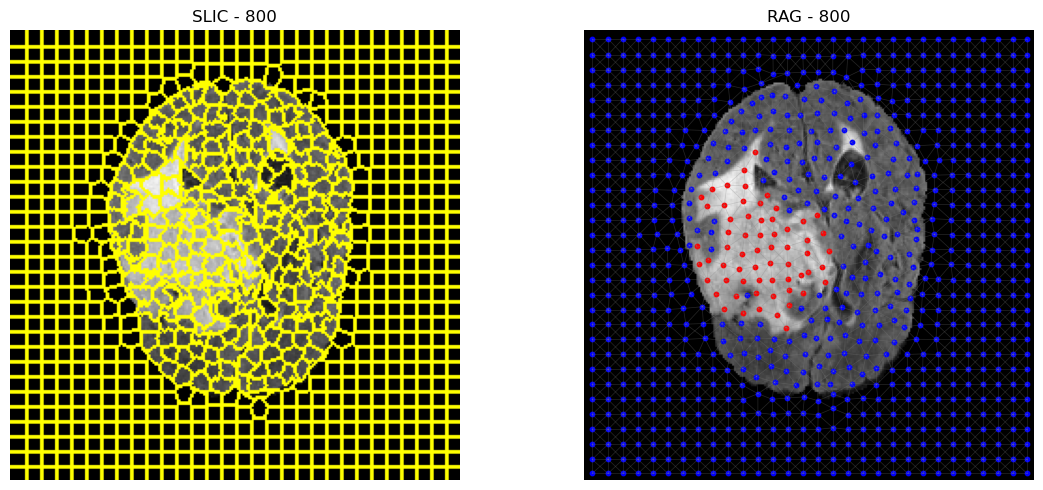

In [ ]:
lista_superpixels = [200, 400, 600, 800]
resultados = []

for n_seg in lista_superpixels:

    
    print(f"Executando Experimento - n_segments = {n_seg}")
    

    # SLIC
    segmentos = slic(
        img_norm,
        n_segments=n_seg,
        compactness=0.1,
        start_label=1,
        channel_axis=None
    )


    # RAG
    G = construir_rag(segmentos)

    # ROTULAGEM
    props = regionprops(segmentos)
    labels_superpixel, pos = rotular_superpixels(props, mask_slice)

    # MÉTRICAS
    metricas = calcular_metricas(G, labels_superpixel)

    resultados.append([
        n_seg,
        G.number_of_nodes(),
        G.number_of_edges(),
        metricas["grau_tumor"],
        metricas["grau_normal"],
        metricas["densidade"],
        metricas["componentes"]
    ])

    print(f"Nós: {G.number_of_nodes()}")
    print(f"Arestas: {G.number_of_edges()}")
    print(f"Densidade: {metricas['densidade']:.4f}")
    print(f"Componentes: {metricas['componentes']}")

  
    # FIGURA (SLIC + RAG)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # SLIC
    axes[0].imshow(mark_boundaries(img_norm, segmentos))
    axes[0].set_title(f"SLIC - {n_seg}")
    axes[0].axis("off")
    
    # RAG
    axes[1].imshow(img_norm, cmap="gray")

    # edges
    for u, v in G.edges():
        x1, y1 = pos[u]
        x2, y2 = pos[v]
        axes[1].plot([x1, x2], [y1, y2], color="gray", alpha=0.3, linewidth=0.5)

   
    tumor_x, tumor_y = [], []
    normal_x, normal_y = [], []

    for node in G.nodes():
        x, y = pos[node]

        if labels_superpixel[node] == "tumor":
            tumor_x.append(x)
            tumor_y.append(y)
        else:
            normal_x.append(x)
            normal_y.append(y)

    axes[1].scatter(tumor_x, tumor_y, c="red", s=10)
    axes[1].scatter(normal_x, normal_y, c="blue", s=10)

    axes[1].set_title(f"RAG - {n_seg}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [14]:
df = pd.DataFrame(
    resultados,
    columns=[
        "Superpixels",
        "Nós",
        "Arestas",
        "Grau Médio Tumor",
        "Grau Médio Normal",
        "Densidade",
        "Componentes"
    ]
)

df

,Superpixels,Nós,Arestas,Grau Médio Tumor,Grau Médio Normal,Densidade,Componentes
0,200,176,506,6.500000,5.695122,0.032857,1
1,400,372,1198,6.166667,6.459770,0.017361,1
2,600,546,1818,6.153846,6.698225,0.012219,1
3,800,854,2928,6.145161,6.912879,0.008039,1
